**Purpose:** To implement permutation testing in R following the tutorial on [geeksforgeeks](https://www.geeksforgeeks.org/r-language/permutation-hypothesis-test-in-r-programming/)\
**Date:** 24/03/2026

In [1]:
# Load package
library(tidyverse)

── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.2.0     ✔ readr     2.2.0
✔ forcats   1.0.1     ✔ stringr   1.6.0
✔ ggplot2   4.0.2     ✔ tibble    3.3.1
✔ lubridate 1.9.5     ✔ tidyr     1.3.2
✔ purrr     1.2.1     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors


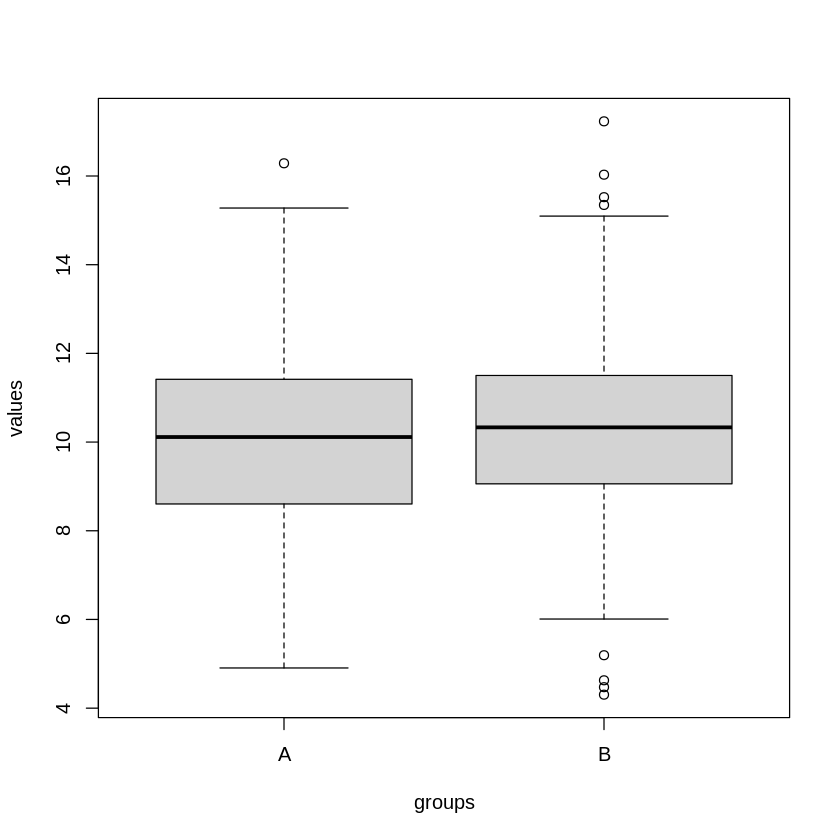

In [2]:
# Make a dataframe
set.seed(2026)
groups <- c(rep("A", 500), rep("B", 500))
values <- c(rnorm(500, mean = 10, sd = 2), rnorm(500, mean = 10.4, sd = 2))
df <- data.frame(
    groups = groups,
    values = values
)
boxplot(values ~ groups, data = df)

In [3]:
# t-test
t.test(values ~ groups, data = df)


	Welch Two Sample t-test

data:  values by groups
t = -2.4215, df = 993.37, p-value = 0.01564
alternative hypothesis: true difference in means between group A and group B is not equal to 0
95 percent confidence interval:
 -0.54915352 -0.05751315
sample estimates:
mean in group A mean in group B 
       10.07587        10.37920 


In [4]:
# Get the test stat, or differences in means
test_stat <- abs(mean(df$values[df$groups == "A"]) - mean(df$values[df$groups == "B"]))
test_stat

[1] 0.3033333

In [5]:
# Permutation
set.seed(2025)
n <- length(df$values)
p <- 10000 # 1000 permutations
variable <- df$values

# Calculate test stat
perm_sample <- matrix(0, nrow = n, ncol = p)
perm_test_stat <- rep(0, p)
# Add the permuted values to the matrix
for (i in 1:p){
  perm_sample[,i] <- sample(variable,
  size = n,
  replace = FALSE)
  perm_test_stat[i] <- abs(mean(perm_sample[df$groups == "A", i]) - mean(perm_sample[df$groups == "B", i]))
}

# Calculate p value
p_value <- mean(perm_test_stat >= test_stat)
p_value

[1] 0.0144

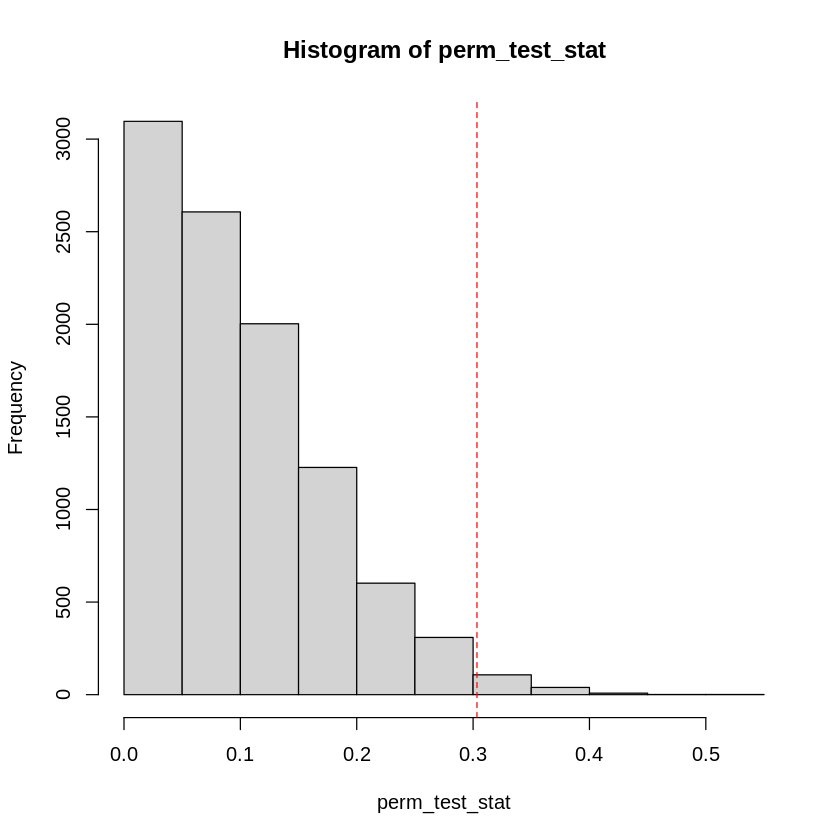

In [6]:
# Visualize
hist(perm_test_stat)
abline(v = test_stat, col = "red", lty = 2)

**Conclusion:** p-values calculated using t-test and permutation tests were similar

In [7]:
sessionInfo()

R version 4.5.3 (2026-03-11)
Platform: x86_64-pc-linux-gnu
Running under: Ubuntu 22.04.5 LTS

Matrix products: default
BLAS:   /usr/lib/x86_64-linux-gnu/openblas-pthread/libblas.so.3 
LAPACK: /usr/lib/x86_64-linux-gnu/openblas-pthread/libopenblasp-r0.3.20.so;  LAPACK version 3.10.0

locale:
 [1] LC_CTYPE=en_US.UTF-8       LC_NUMERIC=C              
 [3] LC_TIME=en_US.UTF-8        LC_COLLATE=en_US.UTF-8    
 [5] LC_MONETARY=en_US.UTF-8    LC_MESSAGES=en_US.UTF-8   
 [7] LC_PAPER=en_US.UTF-8       LC_NAME=C                 
 [9] LC_ADDRESS=C               LC_TELEPHONE=C            
[11] LC_MEASUREMENT=en_US.UTF-8 LC_IDENTIFICATION=C       

time zone: Etc/UTC
tzcode source: system (glibc)

attached base packages:
[1] stats     graphics  grDevices utils     datasets  methods   base     

other attached packages:
 [1] lubridate_1.9.5 forcats_1.0.1   stringr_1.6.0   dplyr_1.2.0    
 [5] purrr_1.2.1     readr_2.2.0     tidyr_1.3.2     tibble_3.3.1   
 [9] ggplot2_4.0.2   tidyverse_2.0.0

loa